# Pokemon Battle Log Batch Analysis

This notebook analyzes Pokémon TCG AI battle log JSON files that you have already saved as a Kaggle Dataset.

## Responsible use / publishing note

- Use this notebook only for your own battle logs, or logs you have permission to analyze.
- Do not publish private battle logs, personal identifiers, access tokens, cookies, API keys, or other secrets.
- This notebook reads local JSON files from Kaggle input. It is not intended to scrape, poll, or repeatedly access external servers.
- Keep usage lightweight: attach a small dataset of saved logs and avoid unnecessary repeated reruns.
- Before publishing, replace the placeholders in the settings cell below with your own Kaggle input path and player name.

This notebook is for exploratory analysis and visualization; it does not submit agents, automate matchmaking, or perform network access.


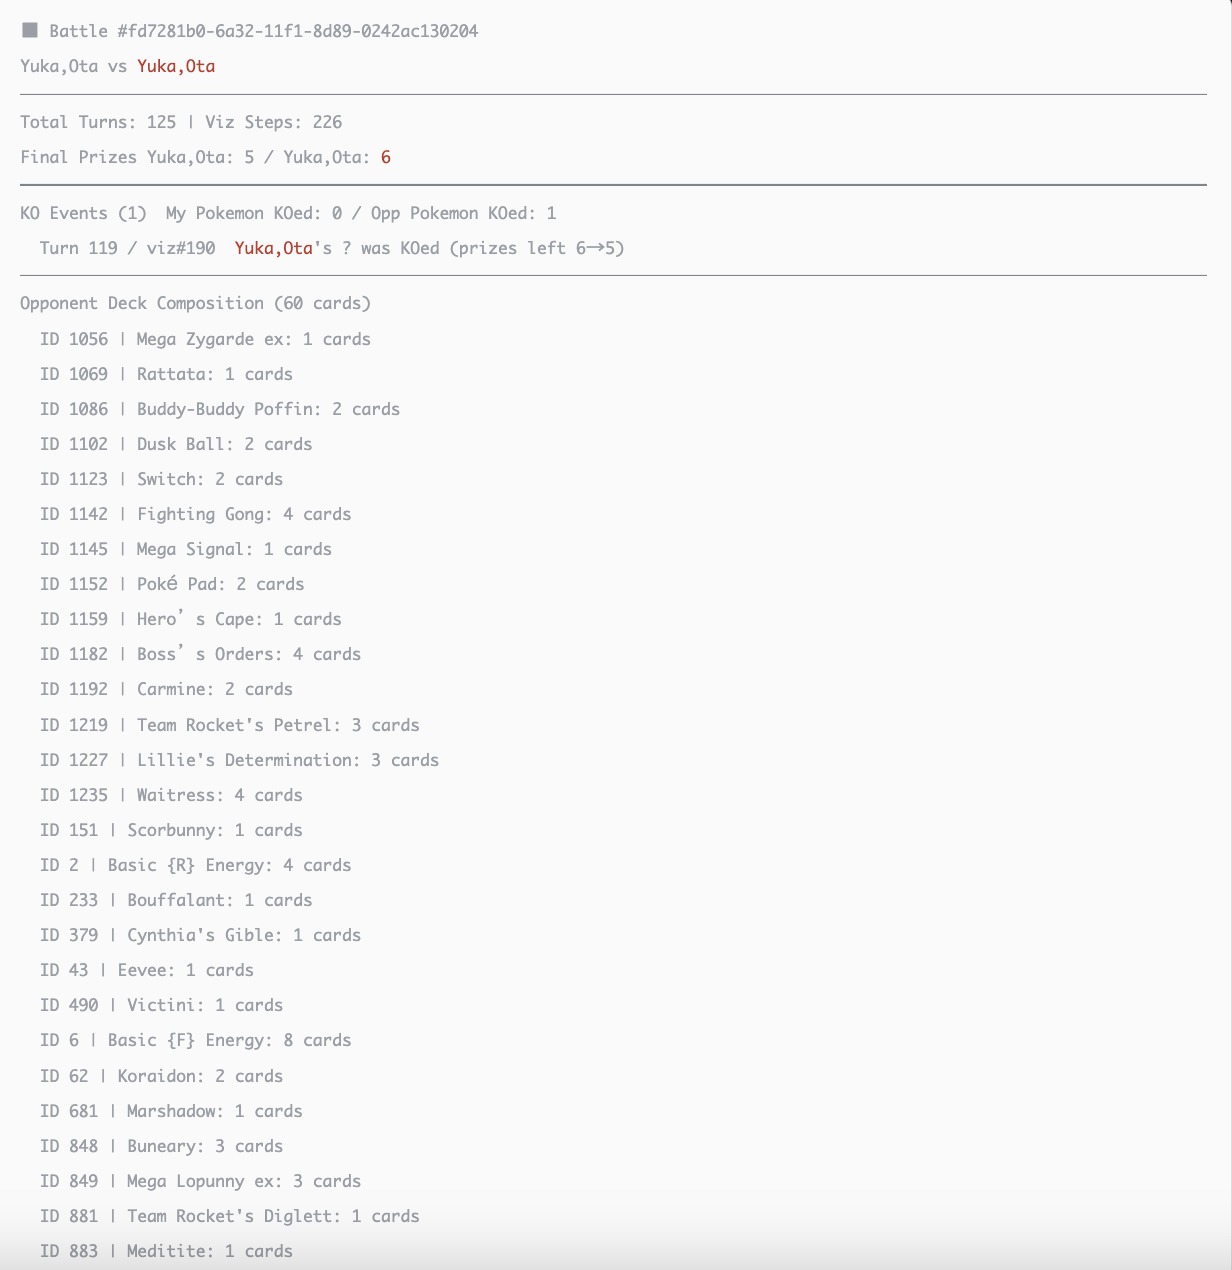

In [1]:
# ========== Settings ==========
# Replace these placeholders before running.
# Example LOG_DIR: "/kaggle/input/your-dataset-slug/battle-loss"
# Example MY_NAME: the exact player name used in your own battle logs.

LOG_DIR = "/kaggle/input/datasets/yukaika/self-loss"  # Folder containing your own JSON battle logs
MY_NAME = "Yuka,Ota"                                # Your player name in the logs

SHOW_GRAPHS = True                                           # Set False to skip graphs
SHOW_DECK = True                                             # Set False to hide deck-count panel
# ==============================


Target files: 1
Parsed successfully: 1 / 1 files


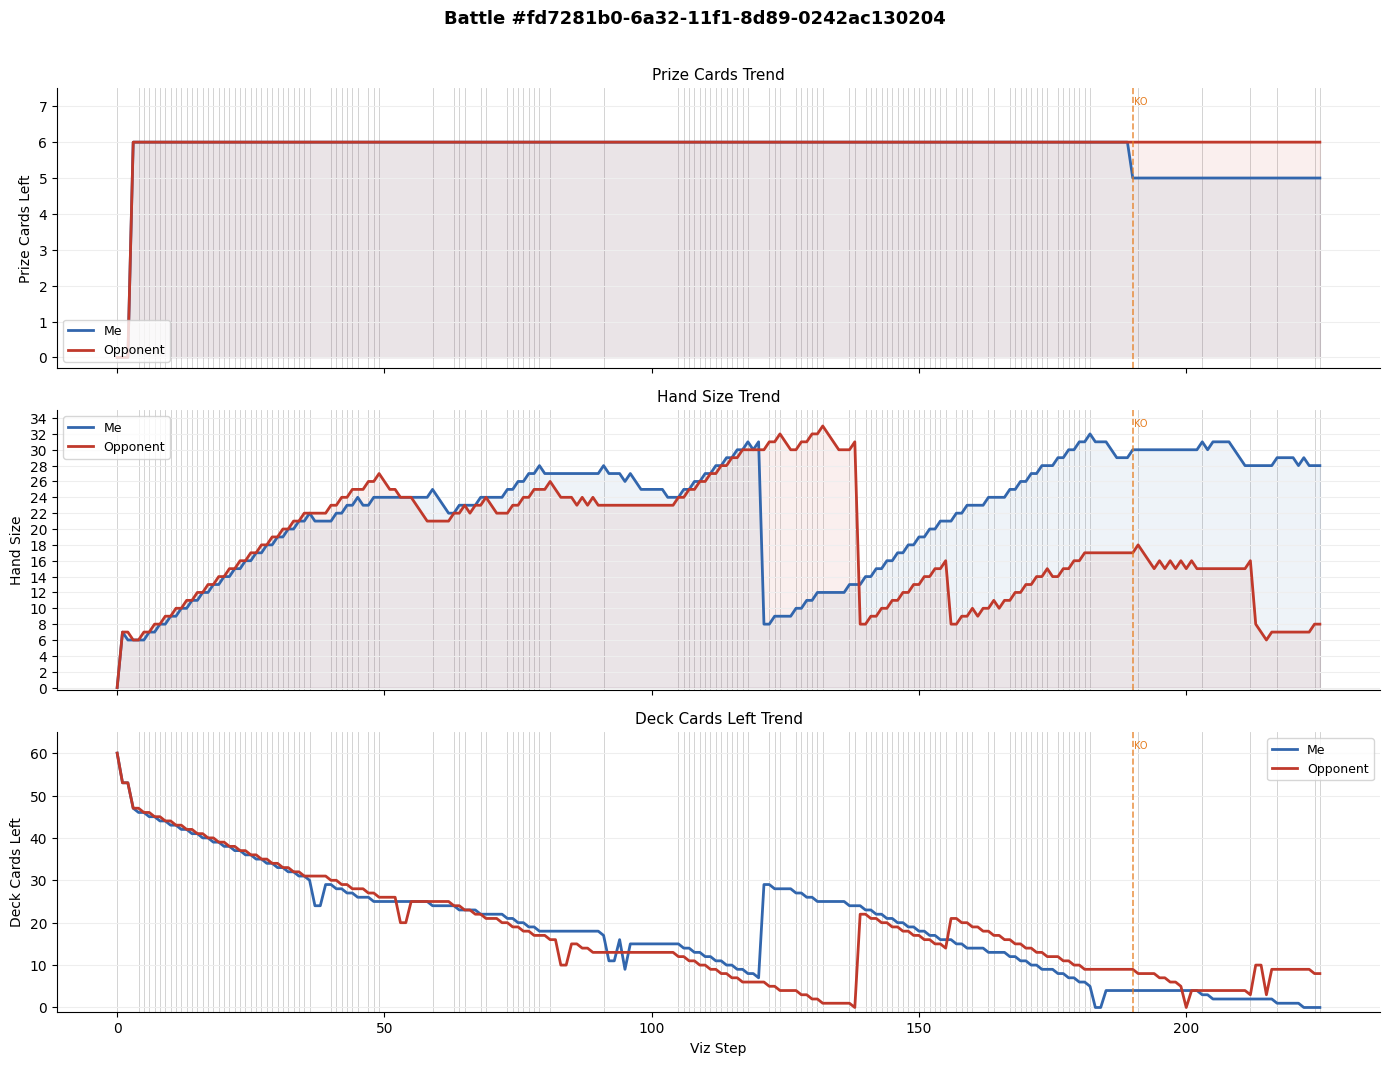

,Episode,Opponent,Turns,My Pokemon KOed,Opp Pokemon KOed,Final Prizes Me,Final Prizes Opp
0,fd7281b0-6a32-11f1-8d89-0242ac130204,"Yuka,Ota",125,0,1,5,6


In [2]:
# ===================================================================
# This single cell contains definitions, loading, and display to avoid cell-order NameError issues.
# ===================================================================

import json
import glob
import os
from collections import Counter
from dataclasses import dataclass, field
from typing import Optional, Any
from html import escape

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display, HTML

# Fallback settings in case the settings cell has not been executed.
LOG_DIR = globals().get("LOG_DIR", "/kaggle/input/YOUR_DATASET_SLUG/YOUR_LOG_FOLDER")
MY_NAME = globals().get("MY_NAME", "YOUR_PLAYER_NAME")
SHOW_GRAPHS = globals().get("SHOW_GRAPHS", True)
SHOW_DECK = globals().get("SHOW_DECK", True)

if "YOUR_DATASET_SLUG" in str(LOG_DIR) or MY_NAME == "YOUR_PLAYER_NAME":
    print("Please edit LOG_DIR and MY_NAME in the settings cell before running on Kaggle.")
    print("LOG_DIR should point to your own uploaded Kaggle Dataset, and MY_NAME should match your player name in the logs.")

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

# This notebook performs local file analysis only; it does not make network requests.

# ---- Color palette ----
C_ME  = '#3266ad'   # Me
C_OPP = '#c0392b'   # Opponent
C_KO  = '#e67e22'   # KO line


@dataclass
class VizFrame:
    """Snapshot for one visualize entry"""
    idx: int
    turn: int
    prize_me: int
    prize_opp: int
    hand_me: int
    hand_opp: int
    deck_me: int
    deck_opp: int
    active_me: Optional[str]
    active_opp: Optional[str]
    hp_opp: Optional[int]
    maxhp_opp: Optional[int]
    log_types: list = field(default_factory=list)


@dataclass
class KOEvent:
    viz_idx: int
    turn: int
    target: str          # 'me' or 'opp'
    pokemon_name: str
    prize_before: int
    prize_after: int


@dataclass
class BattleLog:
    file_path: str
    episode_id: str
    me_name: str
    opp_name: str
    me_index: int
    frames: list
    ko_events: list
    me_deck_ids: list      # list of (card_id, card_name) pairs
    opp_deck_ids: list     # list of (card_id, card_name) pairs


def _as_list(x: Any) -> list:
    if x is None:
        return []
    if isinstance(x, list):
        return x
    return [x]


def _safe_len(player: dict, count_key: str, list_key: str) -> int:
    """Use count key if available; otherwise use list length."""
    if count_key in player and player.get(count_key) is not None:
        try:
            return int(player.get(count_key))
        except Exception:
            pass
    return len(_as_list(player.get(list_key)))


def _get_active(player: dict) -> tuple:
    active = player.get('active', [])
    if isinstance(active, dict):
        a = active
    else:
        active = _as_list(active)
        if not active:
            return None, None, None
        a = active[0]
    if not isinstance(a, dict):
        return str(a), None, None
    return a.get('name'), a.get('hp'), a.get('maxHp')


def _extract_deck_ids(players, player_index: int) -> list:
    """Extract deck cards as (card_id, card_name) pairs.

    The JSON often stores both an id and a human-readable name, e.g.
    {"id": 12345, "name": "Mega Lucario ex"}.
    Returning pairs lets the deck summary show both values.
    """
    try:
        deck_cards = players[player_index].get('deck', [])
        cards = []
        for c in _as_list(deck_cards):
            if not isinstance(c, dict):
                continue

            cid = c.get('id') or c.get('cardId') or c.get('card_id')
            name = c.get('name') or c.get('cardName') or c.get('card_name') or ''

            if cid is None and not name:
                continue

            if cid is not None:
                try:
                    cid = int(cid)
                except Exception:
                    cid = str(cid)

            cards.append((cid, str(name) if name is not None else ''))
        return cards
    except Exception:
        return []


def _format_card_label(card) -> str:
    """Return an HTML-safe label like 'ID 12345 | Mega Lucario ex'."""
    if isinstance(card, tuple):
        cid, name = card
    else:
        # Backward-compatible fallback for old notebooks or precomputed values.
        cid, name = card, ''

    cid_text = '-' if cid is None else str(cid)
    name_text = str(name).strip() if name is not None else ''

    if name_text:
        return f"ID {escape(cid_text)} | {escape(name_text)}"
    return f"ID {escape(cid_text)}"


def _find_visualize(obj: Any) -> list:
    """Recursively find the visualize list in the JSON, even if the path varies."""
    if isinstance(obj, dict):
        viz = obj.get('visualize')
        if isinstance(viz, list):
            return viz
        for v in obj.values():
            found = _find_visualize(v)
            if found:
                return found
    elif isinstance(obj, list):
        for v in obj:
            found = _find_visualize(v)
            if found:
                return found
    return []


def parse_battle_log(json_path: str, my_name: str) -> Optional[BattleLog]:
    """Load a JSON file and convert it to a BattleLog object."""
    try:
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"[ERROR] {json_path}: {e}")
        return None

    episode_id = str(data.get('id', os.path.basename(json_path)))
    agents = data.get('info', {}).get('Agents', [])

    # Identify my/opponent player indices.
    me_index = next((i for i, a in enumerate(agents) if isinstance(a, dict) and a.get('Name') == my_name), None)
    if me_index is None:
        me_index = 0  # Default to player 0 if not found.
    opp_index = 1 if me_index == 0 else 0

    me_name  = agents[me_index].get('Name', 'Me')  if len(agents) > me_index and isinstance(agents[me_index], dict) else 'Me'
    opp_name = agents[opp_index].get('Name', 'Opp') if len(agents) > opp_index and isinstance(agents[opp_index], dict) else 'Opp'

    viz_list = _find_visualize(data)
    if not viz_list:
        print(f"[WARN] {os.path.basename(json_path)}: visualize data was not found")
        return None

    # Extract deck IDs from the initial frame.
    try:
        init_players = viz_list[0]['current']['players']
        me_deck_ids  = _extract_deck_ids(init_players, me_index)
        opp_deck_ids = _extract_deck_ids(init_players, opp_index)
    except Exception:
        me_deck_ids = []
        opp_deck_ids = []

    # Convert all frames.
    frames = []
    for i, viz in enumerate(viz_list):
        if not isinstance(viz, dict):
            continue
        current = viz.get('current', {})
        players = current.get('players', [])
        if len(players) <= max(me_index, opp_index):
            continue

        p_me  = players[me_index]
        p_opp = players[opp_index]
        logs  = viz.get('logs', [])

        name_me,  hp_me,  maxhp_me  = _get_active(p_me)
        name_opp, hp_opp, maxhp_opp = _get_active(p_opp)

        frames.append(VizFrame(
            idx        = i,
            turn       = current.get('turn', 0),
            prize_me   = _safe_len(p_me,  'prizeCount', 'prize'),
            prize_opp  = _safe_len(p_opp, 'prizeCount', 'prize'),
            hand_me    = _safe_len(p_me,  'handCount',  'hand'),
            hand_opp   = _safe_len(p_opp, 'handCount',  'hand'),
            deck_me    = _safe_len(p_me,  'deckCount',  'deck'),
            deck_opp   = _safe_len(p_opp, 'deckCount',  'deck'),
            active_me  = name_me,
            active_opp = name_opp,
            hp_opp     = hp_opp,
            maxhp_opp  = maxhp_opp,
            log_types  = list({l.get('type') for l in logs if isinstance(l, dict)}),
        ))

    if not frames:
        print(f"[WARN] {os.path.basename(json_path)}: no valid frames were found")
        return None

    # Detect KO events. The side with fewer prize cards remaining is the side that took a prize.
    # target means the side whose Pokemon was KOed.
    ko_events = []
    for j in range(1, len(frames)):
        prev, curr = frames[j-1], frames[j]
        if curr.prize_me < prev.prize_me:
            ko_events.append(KOEvent(
                viz_idx=curr.idx, turn=curr.turn, target='opp',
                pokemon_name=prev.active_opp or '?',
                prize_before=prev.prize_me, prize_after=curr.prize_me
            ))
        if curr.prize_opp < prev.prize_opp:
            ko_events.append(KOEvent(
                viz_idx=curr.idx, turn=curr.turn, target='me',
                pokemon_name=prev.active_me or '?',
                prize_before=prev.prize_opp, prize_after=curr.prize_opp
            ))

    return BattleLog(
        file_path  = json_path,
        episode_id = episode_id,
        me_name    = me_name,
        opp_name   = opp_name,
        me_index   = me_index,
        frames     = frames,
        ko_events  = ko_events,
        me_deck_ids  = me_deck_ids,
        opp_deck_ids = opp_deck_ids,
    )


def _add_ko_vlines(ax, ko_events, target_filter=None):
    """Add vertical dashed lines at KO timings."""
    for ev in ko_events:
        if target_filter and ev.target != target_filter:
            continue
        ax.axvline(ev.viz_idx, color=C_KO, lw=1.2, ls='--', alpha=0.8)
        ymax = ax.get_ylim()[1]
        ax.text(ev.viz_idx + 0.3, ymax * 0.97,
                'KO',
                fontsize=7, color=C_KO, va='top', ha='left')


def plot_battle(battle: "BattleLog", show_deck=True):
    """Plot one battle."""
    frames = battle.frames
    if not frames:
        print(f"[SKIP] {battle.episode_id}: no frames")
        return

    xs          = [f.idx for f in frames]
    prize_me    = [f.prize_me  for f in frames]
    prize_opp   = [f.prize_opp for f in frames]
    hand_me     = [f.hand_me   for f in frames]
    hand_opp    = [f.hand_opp  for f in frames]
    deck_me     = [f.deck_me   for f in frames]
    deck_opp    = [f.deck_opp  for f in frames]

    n_rows = 3 if show_deck else 2
    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3.5 * n_rows),
                             facecolor='white', sharex=True)
    if n_rows == 1:
        axes = [axes]
    fig.subplots_adjust(hspace=0.35)

    # 1) Prize cards remaining
    ax = axes[0]
    ax.plot(xs, prize_me,  color=C_ME,  lw=2, label='Me')
    ax.plot(xs, prize_opp, color=C_OPP, lw=2, label='Opponent')
    ax.fill_between(xs, prize_me,  alpha=0.08, color=C_ME)
    ax.fill_between(xs, prize_opp, alpha=0.08, color=C_OPP)
    ax.set_ylabel('Prize Cards Left', fontsize=10)
    ax.set_ylim(-0.3, 7.5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.legend(fontsize=9, loc='lower left')
    ax.set_title('Prize Cards Trend', fontsize=11, pad=6)
    _add_ko_vlines(ax, battle.ko_events)

    # 2) Hand size
    ax = axes[1]
    ax.plot(xs, hand_me,  color=C_ME,  lw=2, label='Me')
    ax.plot(xs, hand_opp, color=C_OPP, lw=2, label='Opponent')
    ax.fill_between(xs, hand_me,  alpha=0.08, color=C_ME)
    ax.fill_between(xs, hand_opp, alpha=0.08, color=C_OPP)
    ax.set_ylabel('Hand Size', fontsize=10)
    ax.set_ylim(-0.3, max(max(hand_me), max(hand_opp), 1) + 2)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.legend(fontsize=9, loc='upper left')
    ax.set_title('Hand Size Trend', fontsize=11, pad=6)
    _add_ko_vlines(ax, battle.ko_events)

    # 3) Deck cards remaining
    if show_deck:
        ax = axes[2]
        ax.plot(xs, deck_me,  color=C_ME,  lw=2, label='Me')
        ax.plot(xs, deck_opp, color=C_OPP, lw=2, label='Opponent')
        ax.set_ylabel('Deck Cards Left', fontsize=10)
        ax.set_ylim(-1, max(max(deck_me), max(deck_opp), 60) + 5)
        ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
        ax.legend(fontsize=9, loc='upper right')
        ax.set_title('Deck Cards Left Trend', fontsize=11, pad=6)
        _add_ko_vlines(ax, battle.ko_events)

    axes[-1].set_xlabel('Viz Step', fontsize=10)
    turn_changes = [f.idx for i, f in enumerate(frames)
                    if i == 0 or f.turn != frames[i-1].turn]
    for ax in axes:
        for tc in turn_changes:
            ax.axvline(tc, color='#cccccc', lw=0.6, ls='-', zorder=0)
        ax.set_facecolor('white')
        ax.grid(axis='y', color='#eeeeee', lw=0.8)

    plt.suptitle(
        f'Battle #{battle.episode_id}',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()


def print_summary(battle: "BattleLog"):
    """Display a battle summary as HTML."""
    frames = battle.frames
    if not frames:
        return

    last = frames[-1]
    ko_me  = [e for e in battle.ko_events if e.target == 'me']
    ko_opp = [e for e in battle.ko_events if e.target == 'opp']
    opp_counts = Counter(battle.opp_deck_ids)

    lines = [
        "<div style='font-family:monospace;font-size:13px;line-height:1.8;border:1px solid #ddd;padding:12px 16px;border-radius:8px;background:#fafafa'>",
        f"<b>■ Battle #{battle.episode_id}</b><br>",
        f"<b>{battle.me_name}</b> vs <b style='color:#c0392b'>{battle.opp_name}</b><br>",
        "<hr style='border:none;border-top:1px solid #eee;margin:6px 0'>",
        f"Total Turns: <b>{last.turn}</b> | Viz Steps: <b>{len(frames)}</b><br>",
        f"Final Prizes  {battle.me_name}: <b>{last.prize_me}</b> / {battle.opp_name}: <b style='color:#c0392b'>{last.prize_opp}</b><br>",
        "<hr style='border:none;border-top:1px solid #eee;margin:6px 0'>",
        f"<b>KO Events ({len(battle.ko_events)})</b>　My Pokemon KOed: <b>{len(ko_me)}</b> / Opp Pokemon KOed: <b>{len(ko_opp)}</b><br>",
    ]

    if not battle.ko_events:
        lines.append("&nbsp;&nbsp;None<br>")
    for ev in battle.ko_events:
        who = 'Me' if ev.target == 'me' else f'<span style="color:#c0392b">{battle.opp_name}</span>'
        lines.append(
            f"&nbsp;&nbsp;Turn {ev.turn} / viz#{ev.viz_idx} &nbsp;"
            f"{who}'s <b>{ev.pokemon_name}</b> was KOed "
            f"(prizes left {ev.prize_before}→{ev.prize_after})<br>"
        )

    if battle.opp_deck_ids:
        lines.append("<hr style='border:none;border-top:1px solid #eee;margin:6px 0'>")
        lines.append(f"<b>Opponent Deck Composition ({len(battle.opp_deck_ids)} cards)</b><br>")
        for card, cnt in sorted(opp_counts.items(), key=lambda x: (str(x[0][0]) if isinstance(x[0], tuple) else str(x[0]), str(x[0][1]) if isinstance(x[0], tuple) and len(x[0]) > 1 else '')):
            lines.append(f"&nbsp;&nbsp;{_format_card_label(card)}: {cnt} cards<br>")

    lines.append("</div>")
    display(HTML(''.join(lines)))


# ===================================================================
# Process all JSON files
# ===================================================================
json_files = sorted(glob.glob(os.path.join(LOG_DIR, '*.json')))
print(f"Target files: {len(json_files)}")

battles = []
for path in json_files:
    b = parse_battle_log(path, MY_NAME)
    if b:
        battles.append(b)

print(f"Parsed successfully: {len(battles)} / {len(json_files)} files")
if len(json_files) == 0:
    print(f"[WARN] No JSON files found in LOG_DIR: {LOG_DIR}")
elif len(battles) == 0:
    print("[WARN] JSON files were found, but none could be parsed. Check MY_NAME or the visualize structure in the JSON files.")

# ===================================================================
# Display graph and summary for each battle
# ===================================================================
if battles:
    for battle in battles:
        print_summary(battle)
        if SHOW_GRAPHS:
            plot_battle(battle, show_deck=SHOW_DECK)
        print('\n' + '='*80 + '\n')

# ===================================================================
# Summary table across all battles
# ===================================================================
summary_columns = [
    'Episode',
    'Opponent',
    'Turns',
    'My Pokemon KOed',       # Number of my Pokemon that were KOed
    'Opp Pokemon KOed',      # Number of opponent Pokemon that were KOed
    'Final Prizes Me',
    'Final Prizes Opp',
]

rows = []
for b in battles:
    my_pokemon_koed  = sum(1 for e in b.ko_events if e.target == 'me')
    opp_pokemon_koed = sum(1 for e in b.ko_events if e.target == 'opp')
    last = b.frames[-1] if b.frames else None
    rows.append({
        'Episode': b.episode_id,
        'Opponent': b.opp_name,
        'Turns': last.turn if last else 0,
        'My Pokemon KOed': my_pokemon_koed,
        'Opp Pokemon KOed': opp_pokemon_koed,
        'Final Prizes Me': last.prize_me if last else None,
        'Final Prizes Opp': last.prize_opp if last else None,
    })

df = pd.DataFrame(rows, columns=summary_columns)


def _add_bar_if_safe(styler, data: pd.DataFrame, column: str, color: str):
    """Apply Styler.bar only when pandas can compute a non-zero range.

    This avoids warnings like:
    RuntimeWarning: invalid value encountered in scalar divide
    when a column is all NaN or has the same value in every row.
    """
    if column not in data.columns:
        return styler
    values = pd.to_numeric(data[column], errors='coerce').dropna()
    if values.empty:
        return styler
    if values.min() == values.max():
        return styler
    return styler.bar(subset=[column], color=color)


if df.empty:
    print("Summary table skipped: no battles were parsed.")
else:
    styler = (
        df.style
        .set_caption('Battle Summary')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}
        ])
        .format({
            'Turns': '{:.0f}',
            'My Pokemon KOed': '{:.0f}',
            'Opp Pokemon KOed': '{:.0f}',
            'Final Prizes Me': '{:.0f}',
            'Final Prizes Opp': '{:.0f}',
        }, na_rep='-')
    )
    styler = _add_bar_if_safe(styler, df, 'My Pokemon KOed', '#aec6e8')
    styler = _add_bar_if_safe(styler, df, 'Opp Pokemon KOed', '#f4b9b9')
    display(styler)
